# Glacier Area and Climate Data Extraction

This notebook extracts annual glacier area and climate variables for Coleman Glacier (Mount Baker, WA) using the Google Earth Engine (GEE) Python API.


## Objectives
Glacier Remote Sensing
1. Process Landsat imagery to calculate glacier area
2. Evaluate compositing strategies (median vs quality mosaic)
3. Perform sensitivity analysis for NDSI and NIR thresholds
4. Generate a final annual glacier area dataset (1984–2024)

Climate Analysis
1. Extract high-resolution climate variables from the PRISM dataset (Temperature and Precipitation).
2. Calculate catchment-scale means to align climate drivers with physical glacier retreat.

## Data Sources
- Landsat imagery
- RGI glacier boundary
- PRISM ANd dataset

Output:
`data/glacier_area.csv`,
`data/climate_variables.csv`

# Environment Setup

In [1]:
# import libraries

# core
import ee
#import folium
import geemap

# data analysis
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import linregress

# visualization
import matplotlib.pyplot as plt
#import matplotlib.dates as mdates
import seaborn as sns
#import plotly.express as px


In [2]:
# trigger the authentication flow
try:
    ee.Initialize(project='colemanglacier')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='colemanglacier')

print("Earth Engine is authenticated and initialized!")

Earth Engine is authenticated and initialized!


# Glacier Area Processing

## Study Area: Coleman Glacier

In [3]:
# load RGI glacier boundary
glacier = ee.FeatureCollection("projects/colemanglacier/assets/coleman_glacier")

# define analysis region
region = glacier.geometry().buffer(1000).bounds()


In [4]:
# display RGI polygon
from IPython.display import Image, display

# terrain background
dem = ee.Image("USGS/SRTMGL1_003")
hillshade = ee.Terrain.hillshade(dem).clip(region)

# create an outline and a semi-transparent fill
outline = ee.Image().paint(glacier, 0, 3) 
fill = ee.Image().paint(glacier, 0).visualize(palette=['#FF0000'], opacity=0.2)

# blend the hillshade, the light fill, and the thick red outline
final_viz = hillshade.visualize(min=150, max=250).blend(fill).blend(outline.visualize(palette=['#FF0000']))

# thumbnail url
url = final_viz.getThumbURL({
    'region': region,
    'dimensions': 800,
    'format': 'png'
})

print("1975 RGI Reference Polygon (Coleman Glacier):")
display(Image(url=url))

1975 RGI Reference Polygon (Coleman Glacier):


## Satellite Data Processing

### Landsat Image Processing

To generate annual glacier observations, Landsat imagery is processed using:
- cloud masking
- reflectance scaling
- NDSI calculation

The workflow is applied separately to Landsat 5, 7, 8, 9 Level 2, Collection 2, Tier 1 datsets

[Landsat 5](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LT05_C02_T1_L2#description) | [Landsat 7](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LE07_C02_T1_L2#description) | [Landsat 8](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2#description) | [Landsat 9](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2#description)

#### Load Landsat Collections

In [5]:
# landsat 5 (1984-1998)
l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
      .filterBounds(glacier)
      .filterDate('1984-01-01', '1998-12-31')
      .filter(ee.Filter.calendarRange(8, 9, 'month')))

# landsat 7 (1999-2012)
l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
      .filterBounds(glacier)
      .filterDate('1999-01-01', '2012-12-31')
      .filter(ee.Filter.calendarRange(8, 9, 'month')))

# landsat 8 (2013-2021) 
l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(glacier)
      .filterDate('2013-01-01', '2024-12-31')
      .filter(ee.Filter.calendarRange(8, 9, 'month')))

# landsat 9 (2023-2024)
l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
      .filterBounds(glacier)
      .filterDate('2022-01-01', '2024-12-31')
      .filter(ee.Filter.calendarRange(8, 9, 'month')))

#### Masking and Scaling Function

In [6]:
# function to define masks for cloud, shadow, and cirrus, and set reflectance scaling

def apply_landsat_mask(image, sensor):
    qa = image.select('QA_PIXEL')
    
    # bits 3 and 4 are universal for cloud/shadow in collection 2
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(
           qa.bitwiseAnd(1 << 4).eq(0))

    # bit 1 is universal for dilated cloud
    mask = mask.And(qa.bitwiseAnd(1 << 1).eq(0))

    # sensor-specific cirrus logic
    # l5 has no cirrus bit
    if sensor in ['L8', 'L9']:
        # l8 and l9: cirrus is bit 2
        mask = mask.And(qa.bitwiseAnd(1 << 2).eq(0))
    elif sensor == 'L7':
        # l7: cirrus is high confidence (value 3) in bits 14-15
        mask = mask.And(qa.bitwiseAnd(3 << 14).neq(3 << 14))

    # scaling factors 
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    
    return image.addBands(optical, overwrite=True).updateMask(mask)

# wrapper functions
def mask_l5(image): return apply_landsat_mask(image, 'L5')
def mask_l7(image): return apply_landsat_mask(image, 'L7')
def mask_l8(image): return apply_landsat_mask(image, 'L8')
def mask_l9(image): return apply_landsat_mask(image, 'L9')

#### NDSI Calculation

$NDSI=\frac{Green + SWIR}{Green - SWIR}$

In [7]:
# compute NDSI and add it as a new band to each Landsat image

# l5 and l7: band 2 is green and band 5 is shortwave infrared
def add_ndsi_l5_l7(image):
    ndsi = image.normalizedDifference(['SR_B2', 'SR_B5']).rename('NDSI')
    return image.addBands(ndsi)

# l8 and l9: band 3 is green and band 6 is shortwave infrared
def add_ndsi_l8_l9(image):
    ndsi = image.normalizedDifference(['SR_B3', 'SR_B6']).rename('NDSI')
    return image.addBands(ndsi)

### Annual Composite Generation

Two compositing strategies are evaluated:

• Median composite – reduces noise by averaging pixel values  
• Quality mosaic – selects pixels with highest NDSI values

These approaches help determine the most stable method for glacier delineation.

In [8]:
# create annual composite
def annual_composite(ic, year, mask_fn, ndsi_fn, sensor_label, method='median'):
    year = ee.Number(year)

    imgs = (ic
            .filter(ee.Filter.calendarRange(year, year, 'year')) # filter by year
            .map(mask_fn) # apply QA_PIXEL mask
            .map(ndsi_fn) # compute NDSI
    )

    # reducer: median or quality mosaic
    composite = ee.Algorithms.If(
        ee.String(method).equals('quality'),
        imgs.qualityMosaic('NDSI'),
        imgs.median()
    )

    return (ee.Image(composite)
            .set({
                'year': year, # compute pixel-wise median across all images in that year
                'count': imgs.size(), # store number of images
                'sensor': sensor_label,
                'method': method
        })
    )

In [9]:
# wrapper functions for each sensor group

# L5
def annual_l5_median(year):
    return annual_composite(l5, year, mask_l5, add_ndsi_l5_l7, 'L5', 'median')

def annual_l5_quality(year):
    return annual_composite(l5, year, mask_l5, add_ndsi_l5_l7, 'L5', 'quality')

# L7
def annual_l7_median(year):
    return annual_composite(l7, year, mask_l7, add_ndsi_l5_l7, 'L7', 'median')

def annual_l7_quality(year):
    return annual_composite(l7, year, mask_l7, add_ndsi_l5_l7, 'L7', 'quality')

# L8
def annual_l8_median(year):
    return annual_composite(l8, year, mask_l8, add_ndsi_l8_l9, 'L8', 'median')

def annual_l8_quality(year):
    return annual_composite(l8, year, mask_l8, add_ndsi_l8_l9, 'L8', 'quality')

# L9
def annual_l8_l9_median(year):
    return annual_composite(l9, year, mask_l9, add_ndsi_l8_l9, 'L9', 'median')

def annual_l8_l9_quality(year):
    return annual_composite(l9, year, mask_l9, add_ndsi_l8_l9, 'L9', 'quality')


### Glacier Delineation

Glacier area is extracted using a combination of:

• NDSI threshold (snow/ice detection)  
• NIR reflectance threshold (removes fresh snow)

Area is calculated using pixel area within the glacier boundary.

In [10]:
def glacier_area_threshold(image, ndsi_threshold, nir_threshold):

    # identify sensor from composite metadata
    sensor_name = ee.String(image.get('sensor'))

    is_modern_sensor = sensor_name.match('L8|L9')

    # select NIR band based on sensor (L8/L9 = SR_B5, L5/L7 = SR_B4)
    nir_band = ee.Algorithms.If(
        is_modern_sensor,
        image.select('SR_B5'),
        image.select('SR_B4')
    )

    # ndsi_mask: NDSI threshold (snow + ice)
    ndsi_mask = image.select('NDSI').gt(ndsi_threshold)

    # ice_filter: NIR ice threshold (isolates ice from fresh snow)
    ice_filter = ee.Image(nir_band).gt(nir_threshold)

    # combine masks
    mask = ndsi_mask.And(ice_filter).selfMask().clip(glacier)

    # compute area
    region_dict = mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=glacier,
        scale=30,
        maxPixels=1e9
    )

    # safely get area or zero if no pixels
    vals = region_dict.values()

    # 2. If the list has items, get the first one. Otherwise, return 0.
    area_m2 = ee.Number(ee.Algorithms.If(vals.size().gt(0), vals.get(0), 0))
    
    return ee.Feature(
        glacier.geometry().centroid(1),
        {
            'year': image.get('year'),
            'sensor': image.get('sensor'),
            'method': image.get('method'),
            'image_count': image.get('count'),
            'glacier_area_m2': area_m2,
            'ndsi_threshold': ndsi_threshold,
            'nir_threshold': nir_threshold
        }
    )

In [11]:
# L5 
years_l5 = ee.List.sequence(1984, 1998)
annual_ic_l5_median  = ee.ImageCollection(years_l5.map(annual_l5_median))
annual_ic_l5_quality = ee.ImageCollection(years_l5.map(annual_l5_quality))

# L7 
years_l7 = ee.List.sequence(1999, 2012)
annual_ic_l7_median  = ee.ImageCollection(years_l7.map(annual_l7_median))
annual_ic_l7_quality = ee.ImageCollection(years_l7.map(annual_l7_quality))

# L8 
years_l8 = ee.List.sequence(2013, 2021)
annual_ic_l8_median  = ee.ImageCollection(years_l8.map(annual_l8_median))
annual_ic_l8_quality = ee.ImageCollection(years_l8.map(annual_l8_quality))

# L8 + L9 Combined
years_combined = ee.List.sequence(2022, 2024)

# Helper functions to merge L8 and L9 into one pool for these years
def annual_l8_l9_median(y): 
    return annual_composite(l8.merge(l9), y, mask_l8, add_ndsi_l8_l9, 'L8+L9', 'median')

def annual_l8_l9_quality(y): 
    return annual_composite(l8.merge(l9), y, mask_l8, add_ndsi_l8_l9, 'L8+L9', 'quality')

annual_ic_l8_l9_median  = ee.ImageCollection(years_combined.map(annual_l8_l9_median))
annual_ic_l8_l9_quality = ee.ImageCollection(years_combined.map(annual_l8_l9_quality))

## Sensitivity Analysis

### Composite Method Comparison


In [12]:
# define fixed parameters
ndsi_fixed = 0.4
nir_fixed = 0.2
results = []

# prepare the thresholds as EE objects for the lambda function
t_ee = ee.Number(ndsi_fixed)
n_ee = ee.Number(nir_fixed)

# Use .map() to apply the area function across all collections
fc_l5_med = annual_ic_l5_median.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l5_qual = annual_ic_l5_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

fc_l7_med = annual_ic_l7_median.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l7_qual = annual_ic_l7_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

fc_l8_med = annual_ic_l8_median.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l8_qual = annual_ic_l8_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

fc_l8_l9_med = annual_ic_l8_l9_median.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l8_l9_qual = annual_ic_l8_l9_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

# combine all sensor data, but keep Median and Quality separate for df columns
data_med = fc_l5_med.merge(fc_l7_med).merge(fc_l8_med).merge(fc_l8_l9_med).getInfo()
data_qual = fc_l5_qual.merge(fc_l7_qual).merge(fc_l8_qual).merge(fc_l8_l9_qual).getInfo()

# extract properties and align them into a single list
for i in range(len(data_med['features'])):
    m_props = data_med['features'][i]['properties']
    q_props = data_qual['features'][i]['properties']

    results.append({
        'year': m_props['year'],
        'sensor': m_props['sensor'],
        'area_km2_median': m_props['glacier_area_m2'] / 1e6,
        'area_km2_quality': q_props['glacier_area_m2'] / 1e6,
        'ndsi_threshold': m_props['ndsi_threshold'],
        'nir_threshold': m_props['nir_threshold']
    })

df_composite = pd.DataFrame(results).sort_values('year').reset_index(drop=True)


In [13]:
# MAD helper function
def mad(data):
    return np.mean(np.abs(data - np.mean(data)))

In [14]:
# calculate the overall MAD for the entire period
global_mad_median = mad(df_composite['area_km2_median'])
global_mad_quality = mad(df_composite['area_km2_quality'])

print(f"Global Variability (MAD) - Median: {global_mad_median:.2f} km²")
print(f"Global Variability (MAD) - Quality: {global_mad_quality:.2f} km²")

Global Variability (MAD) - Median: 0.50 km²
Global Variability (MAD) - Quality: 0.43 km²


In [15]:
# calculate a 5-year rolling MAD
df_composite['rolling_mad_med'] = df_composite['area_km2_median'].rolling(window=5).apply(mad)
df_composite['rolling_mad_qual'] = df_composite['area_km2_quality'].rolling(window=5).apply(mad)

print(f"Average Rolling Stability - Median: {df_composite['rolling_mad_med'].mean():.2f} km²")
print(f"Average Rolling Stability - Quality: {df_composite['rolling_mad_qual'].mean():.2f} km²")

Average Rolling Stability - Median: 0.36 km²
Average Rolling Stability - Quality: 0.34 km²


In [16]:
# visualize median vs quality mosaic composites
# define visual parameters
vis_params = {'bands': ['SR_B5', 'SR_B4', 'SR_B3'], 'min': 0, 'max': 0.4, 'gamma': 1.2}

# test year: 2020
test_year = 2020
img_med = annual_l8_median(test_year)
img_qual = annual_l8_quality(test_year)

# create vector outlines, convert masks to vectors
def get_outline(mask, color):
    return mask.reduceToVectors(
        geometry=glacier,
        scale=30,
        geometryType='polygon',
        eightConnected=True
    ).style(color=color, fillColor='00000000', width=2)

# apply thresholds
mask_med = img_med.select('NDSI').gt(0.4).And(img_med.select('SR_B5').gt(0.20)).clip(glacier)
mask_qual = img_qual.select('NDSI').gt(0.4).And(img_qual.select('SR_B5').gt(0.20)).clip(glacier)

outline_med = get_outline(mask_med, 'orange')
outline_qual = get_outline(mask_qual, 'green')

# create the map
Map = geemap.Map()
Map.centerObject(glacier, 15) # zoom in on the terminus

# add cleanest image as background
Map.addLayer(img_qual, vis_params, 'False Color Background (NIR-R-G)')

# add  boundaries
Map.addLayer(outline_med, {}, 'Median Composite Boundary (Orange)')
Map.addLayer(outline_qual, {}, 'Quality Mosaic Boundary (Green)')

# add a gain/loss layer
gain_pixels = mask_qual.subtract(mask_med).gt(0).selfMask()
Map.addLayer(gain_pixels, {'palette': 'cyan'}, 'Pixels captured only by Quality Mosaic')

Map.add_legend(title="Delineation Comparison",
               colors=['#FFA500', '#008000', '#00FFFF'],
               keys=['Median Boundary', 'Quality Boundary', 'Captured Ice Gain'])
Map

Map(center=[48.784220202434916, -121.8503476207567], controls=(WidgetControl(options=['position', 'transparent…

### NDSI Threshold Sensitivity


In [17]:
# define parameter space
ndsi_thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
nir_fixed = 0.2
rows = []

for t in ndsi_thresholds:
    t_ee = ee.Number(t)
    n_ee = ee.Number(nir_fixed)

    # map over Quality collections
    fc_l5 = annual_ic_l5_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l7 = annual_ic_l7_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l8 = annual_ic_l8_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l8_l9 = annual_ic_l8_l9_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

    # merge all sensors for this specific threshold
    fc_all_thresh = fc_l5.merge(fc_l7).merge(fc_l8).merge(fc_l8_l9)

    # convert the results from the server to a Python list
    data = fc_all_thresh.getInfo()

    for f in data['features']:
        props = f['properties']
        rows.append({
            'year': props['year'],
            'sensor': props['sensor'],
            'method': props['method'],
            'image_count': props.get('image_count'),
            'ndsi_threshold': props['ndsi_threshold'],
            'nir_threshold': props['nir_threshold'],
            'glacier_area_km2': props['glacier_area_m2'] / 1e6
        })

df_ndsi_threshold = pd.DataFrame(rows)

# create summary table
ndsi_analysis = df_ndsi_threshold.groupby('ndsi_threshold')['glacier_area_km2'].agg([
    'mean', 'std'
]).copy()

# calculate CV and MAD
ndsi_analysis['CV_percent'] = (ndsi_analysis['std'] / ndsi_analysis['mean']) * 100
ndsi_analysis['MAD'] = df_ndsi_threshold.groupby('ndsi_threshold')['glacier_area_km2'].apply(
    lambda x: np.mean(np.abs(x - np.mean(x)))
).values

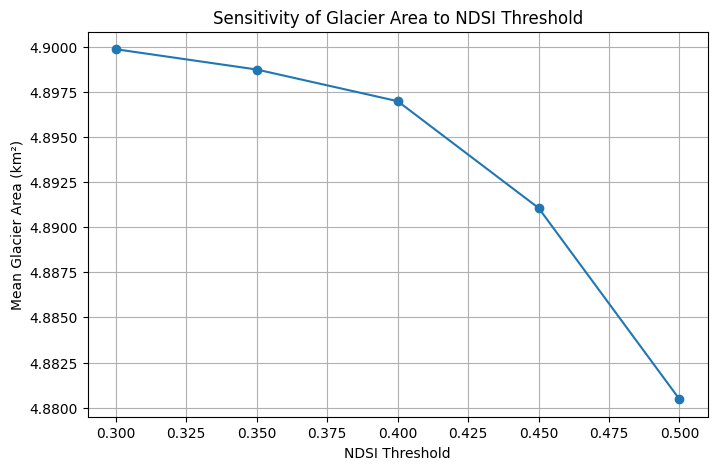

In [18]:
# plot mean area
plt.figure(figsize=(8,5))

plt.plot(ndsi_analysis.index, ndsi_analysis['mean'], marker='o')

plt.xlabel("NDSI Threshold")
plt.ylabel("Mean Glacier Area (km²)")
plt.title("Sensitivity of Glacier Area to NDSI Threshold")
plt.grid(True)
plt.show()


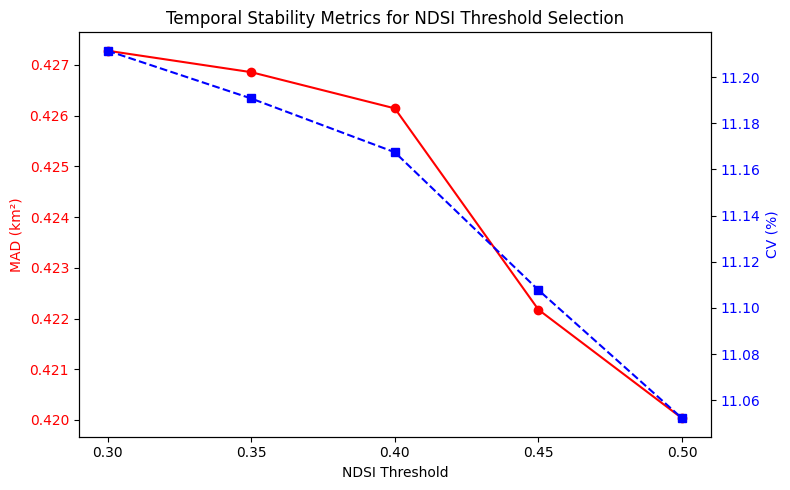

In [19]:
# plot MAD and CV
fig, ax1 = plt.subplots(figsize=(8, 5))

# plot MAD 
ax1.set_xlabel('NDSI Threshold')
ax1.set_ylabel('MAD (km²)', color='red')
ax1.plot(ndsi_analysis.index, ndsi_analysis['MAD'], 'ro-', label='MAD')
ax1.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(ndsi_analysis.index)

# create secondary y-axis for CV
ax2 = ax1.twinx()
ax2.set_ylabel('CV (%)', color='blue')
ax2.plot(ndsi_analysis.index, ndsi_analysis['CV_percent'], 'bs--', label='CV')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Temporal Stability Metrics for NDSI Threshold Selection')
fig.tight_layout()
plt.show()

### NIR Threshold Sensitivity

In [20]:
# define parameter space
nir_thresholds = [0.1, 0.15, 0.2, 0.25, 0.3]
ndsi_fixed = 0.4
nir_rows = []

for n in nir_thresholds:
    t_ee = ee.Number(ndsi_fixed)
    n_ee = ee.Number(n)

    # map over Quality collections
    fc_l5 = annual_ic_l5_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l7 = annual_ic_l7_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l8 = annual_ic_l8_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
    fc_l8_l9 = annual_ic_l8_l9_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))

    data = fc_l5.merge(fc_l7).merge(fc_l8).merge(fc_l8_l9).getInfo()

    for f in data['features']:
        props = f['properties']
        rows.append({
            'year': props['year'],
            'sensor': props['sensor'],
            'method': props['method'],
            'image_count': props.get('image_count'),
            'ndsi_threshold': props['ndsi_threshold'],
            'nir_threshold': props['nir_threshold'],
            'glacier_area_km2': props['glacier_area_m2'] / 1e6
        })

df_nir_threshold = pd.DataFrame(rows)

# create summary table
nir_analysis = df_nir_threshold.groupby('nir_threshold')['glacier_area_km2'].agg([
    'mean', 'std'
]).copy()

# calculate CV and MAD
nir_analysis['CV_percent'] = (nir_analysis['std'] / nir_analysis['mean']) * 100
nir_analysis['MAD'] = df_nir_threshold.groupby('nir_threshold')['glacier_area_km2'].apply(
    lambda x: np.mean(np.abs(x - np.mean(x)))
).values


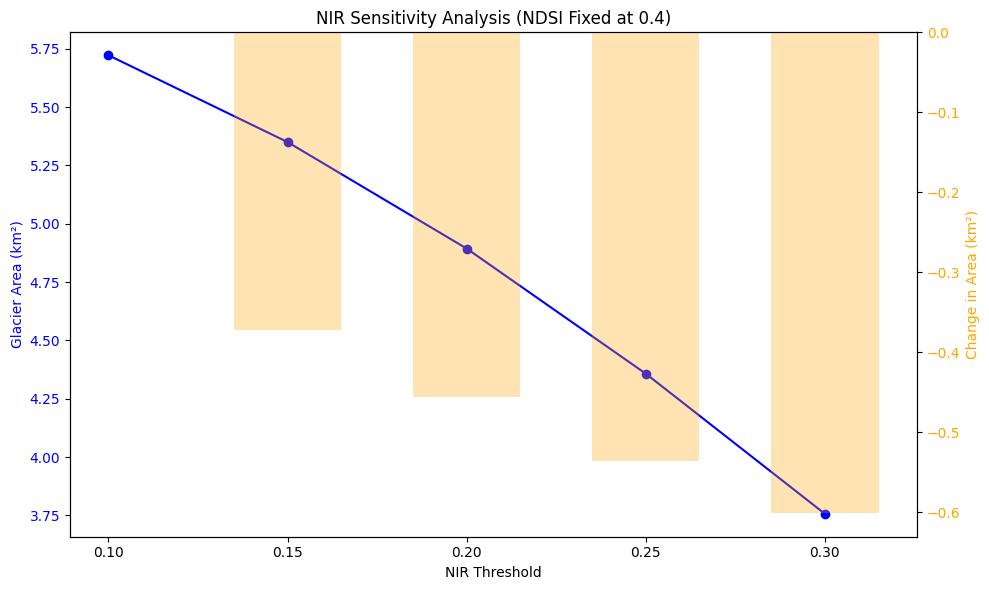

In [21]:
# calculate the change between steps 
nir_analysis['area_change'] = nir_analysis['mean'].diff()

fig, ax1 = plt.subplots(figsize=(10, 6))

# plot mean area
ax1.plot(nir_analysis.index, nir_analysis['mean'], 'b-o', label='Mean Area')
ax1.set_xlabel('NIR Threshold')
ax1.set_ylabel('Glacier Area (km²)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# plot the change
ax2 = ax1.twinx()
ax2.bar(nir_analysis.index, nir_analysis['area_change'], alpha=0.3, color='orange', width=0.03, label='Area Change')
ax2.set_ylabel('Change in Area (km²)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title(f'NIR Sensitivity Analysis (NDSI Fixed at {ndsi_fixed})')
fig.tight_layout()
plt.show()

## Final Glacier Area Dataset

In [22]:
# summary table of final parameters
final_params = pd.DataFrame({
    "Parameter": ["Composite", "NDSI Threshold", "NIR Threshold"],
    "Value": ["Quality Mosaic", 0.4, 0.2]
})

display(final_params)

,Parameter,Value
0,Composite,Quality Mosaic
1,NDSI Threshold,0.4
2,NIR Threshold,0.2


### Final Annual Glacier Area Estimates

In [23]:
# final parameters
FINAL_NDSI = 0.4
FINAL_NIR = 0.2

# prepare EE constants
t_ee = ee.Number(FINAL_NDSI)
n_ee = ee.Number(FINAL_NIR)

# apply area function to Quality Mosaic collections
fc_l5 = annual_ic_l5_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l7 = annual_ic_l7_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l8 = annual_ic_l8_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))
fc_l8_l9 = annual_ic_l8_l9_quality.map(lambda img: glacier_area_threshold(img, t_ee, n_ee))


# merge and pull  data
final_data = fc_l5.merge(fc_l7).merge(fc_l8).merge(fc_l8_l9).getInfo()

# parse into final df
final_rows = []
for f in final_data['features']:
    props = f['properties']
    final_rows.append({
        'year': props['year'],
        'sensor': props['sensor'],
        'method': props['method'],
        'image_count': props.get('image_count'),
        'ndsi_threshold': FINAL_NDSI,
        'nir_threshold': FINAL_NIR,
        'glacier_area_km2': props['glacier_area_m2'] / 1e6
    })

df_glacier_final = pd.DataFrame(final_rows).sort_values('year').reset_index(drop=True)

display(df_glacier_final.head())

,year,sensor,method,image_count,ndsi_threshold,nir_threshold,glacier_area_km2
0,1984,L5,quality,4,0.4,0.2,5.934645
1,1985,L5,quality,5,0.4,0.2,4.755392
2,1986,L5,quality,7,0.4,0.2,5.450218
3,1987,L5,quality,7,0.4,0.2,4.576846
4,1988,L5,quality,6,0.4,0.2,5.153083


In [24]:
df_glacier_final.tail(10)

,year,sensor,method,image_count,ndsi_threshold,nir_threshold,glacier_area_km2
31,2015,L8,quality,7,0.4,0.2,4.357385
32,2016,L8,quality,8,0.4,0.2,5.151688
33,2017,L8,quality,7,0.4,0.2,5.658004
34,2018,L8,quality,7,0.4,0.2,4.939766
35,2019,L8,quality,5,0.4,0.2,4.016973
36,2020,L8,quality,7,0.4,0.2,4.943487
37,2021,L8,quality,7,0.4,0.2,3.669908
38,2022,L8+L9,quality,16,0.4,0.2,4.522109
39,2023,L8+L9,quality,13,0.4,0.2,3.282594
40,2024,L8+L9,quality,14,0.4,0.2,4.366541


### Key Metrics Summary

In [25]:

# define median absolute deviation
def get_mad(x):
    return (x - x.median()).abs().median()

# calculate  rolling MAD (using a 5-year window)
df_glacier_final['rolling_mad'] = df_glacier_final['glacier_area_km2'].rolling(window=5, center=True).apply(get_mad)

# calculate global uncertainty (mean of the rolling MADs)
global_uncertainty = df_glacier_final['rolling_mad'].mean()

# extract key metrics
start_val = df_glacier_final.iloc[0]['glacier_area_km2']
end_val = df_glacier_final.iloc[-1]['glacier_area_km2']
net_change = end_val - start_val
pct_change = (net_change / start_val) * 100

# extract min area and year
min_area = df_glacier_final['glacier_area_km2'].min()
min_year = df_glacier_final.loc[df_glacier_final['glacier_area_km2'].idxmin(), 'year']

# create summary table
summary_dict = {
    'Metric': [
        'Initial Area (1984)',
        'Final Area (2020)',
        'Net Area Change',
        'Percentage Change',
        f'Minimum Area Observed ({int(min_year)})',
        'Mean Study Area',
        'Estimated Uncertainty (MAD)'
    ],
    'Value': [
        f"{start_val:.3f} km²",
        f"{end_val:.3f} km²",
        f"{net_change:.3f} km²",
        f"{pct_change:.1f}%",
        f"{min_area:.3f} km²",
        f"{df_glacier_final['glacier_area_km2'].mean():.3f} km²",
        f"± {global_uncertainty:.3f} km²"
    ]
}

summary_df = pd.DataFrame(summary_dict)
print(summary_df.to_string(index=False))


                      Metric       Value
         Initial Area (1984)   5.935 km²
           Final Area (2020)   4.367 km²
             Net Area Change  -1.568 km²
           Percentage Change      -26.4%
Minimum Area Observed (2023)   3.283 km²
             Mean Study Area   4.897 km²
 Estimated Uncertainty (MAD) ± 0.285 km²


### Annual Glacier Area and 5-Year Moving Average with Uncertainty

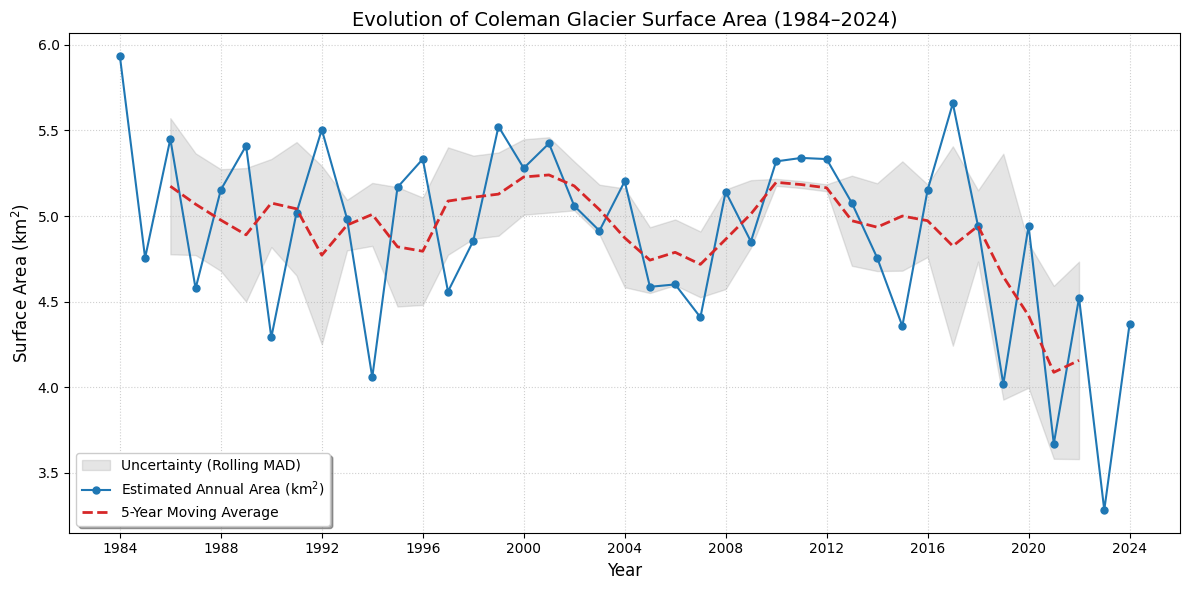

In [26]:
# calculate 5-year moving average
df_glacier_final['glacier_5_moving_avg'] = df_glacier_final['glacier_area_km2'].rolling(window=5, center=True).mean()
df_glacier_final['rolling_mad'] = df_glacier_final['glacier_area_km2'].rolling(window=5, center=True).apply(lambda x: (x - x.median()).abs().median())

# plot
plt.figure(figsize=(12, 6))

# plot uncertainty envelope
plt.fill_between(df_glacier_final['year'],
                 df_glacier_final['glacier_5_moving_avg'] - df_glacier_final['rolling_mad'],
                 df_glacier_final['glacier_5_moving_avg'] + df_glacier_final['rolling_mad'],
                 color='gray', alpha=0.2, label='Uncertainty (Rolling MAD)')

# plot annual area
plt.plot(df_glacier_final['year'], df_glacier_final['glacier_area_km2'],
         marker='o', color='#1f77b4', linewidth=1.5, markersize=5,
         label='Estimated Annual Area (km$^2$)')

# plot moving average
plt.plot(df_glacier_final['year'], df_glacier_final['glacier_5_moving_avg'],
         color='#d62728', linestyle='--', linewidth=2,
         label='5-Year Moving Average')

plt.title('Evolution of Coleman Glacier Surface Area (1984–2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Surface Area (km$^2$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, shadow=True)
plt.xticks(range(1984, 2025, 4))
plt.tight_layout()
plt.show()

### Key Year Glacier Extent (1984, 1994, 2010, 2020)
The following images show the glacier outline (red) and ice extent (cyan/blue) for selected years.

In [27]:
from IPython.display import Image, display, HTML

# plot glacier images

glacier = ee.FeatureCollection("projects/colemanglacier/assets/coleman_glacier")
region = glacier.geometry().buffer(800).bounds() # Slightly wider view
dem = ee.Image("USGS/SRTMGL1_003")
hillshade = ee.Terrain.hillshade(dem).clip(region)
rgi_outline = ee.Image().paint(glacier, 1, 3)

key_years = [1984, 1994, 2010, 2020]
urls = []

for year in key_years:
    if year < 1999:
        img = annual_l5_quality(year); nir = 'SR_B4'
    elif year < 2013:
        img = annual_l7_quality(year); nir = 'SR_B4'
    else:
        img = annual_l8_quality(year); nir = 'SR_B5'

    mask = img.select('NDSI').gt(0.4).And(img.select(nir).gt(0.20)).selfMask().clip(glacier)

    # base hillshade
    bg_viz = hillshade.visualize(min=150, max=250, opacity=1.0)

    # glacier body
    ice_viz = mask.visualize(palette=['#00ffff', '#3288bd'], min=0, max=1, opacity=0.9)

    # RGI outline
    outline_viz = rgi_outline.visualize(palette=['#FF0000'])

    final_viz = bg_viz.blend(ice_viz).blend(outline_viz)

    url = final_viz.getThumbURL({'region': region, 'dimensions': 600, 'format': 'png'})
    urls.append(url)

# display grid

html_content = f"""
<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; background: #f0f0f0; padding: 15px;">
    {"".join([f'''
        <div style="text-align:center; background:white; padding:10px; color:black;">
            <b style="font-size: 16px;">{yr}</b><br>
            <img src="{url}" width="100%">
        </div>
    ''' for yr, url in zip(key_years, urls)])}
</div>
"""
display(HTML(html_content))

### Glacier Retreat Trend
Linear regression shows the rate of area loss over 1984–2020.

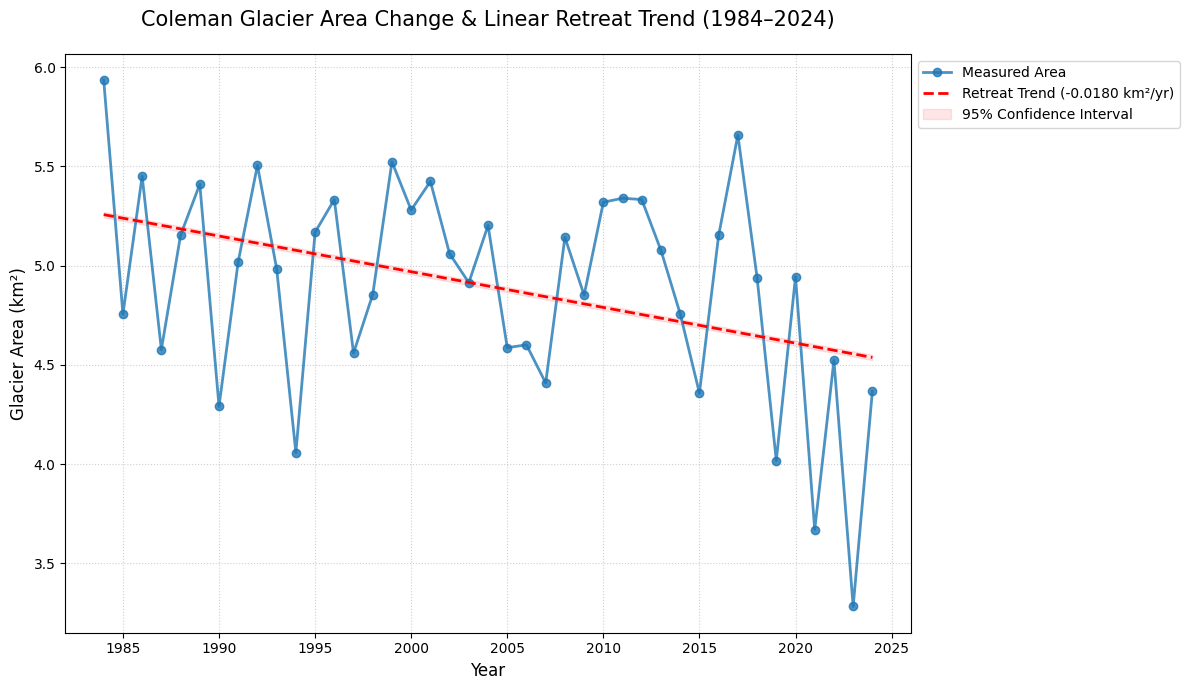


--- Coleman Glacier Retreat Summary ---
Annual Loss Rate: 0.0180 km²/year
Total Area Change (1984-2024): -1.57 km²
P-value: 0.010792404843969433
R-squared: 0.155


In [28]:
# prepare data
x = df_glacier_final['year']
y = df_glacier_final['glacier_area_km2']

# calculate slope
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# create a line of best fit
line = slope * x + intercept

# visualize
plt.figure(figsize=(12,7))
plt.plot(x, y, marker='o', linestyle='-', linewidth=2, label='Measured Area', alpha=0.8)
plt.plot(x, line, color='red', linestyle='--', linewidth=2, label=f'Retreat Trend ({slope:.4f} km²/yr)')

# confidence interval
plt.fill_between(x, line - std_err*2, line + std_err*2, color='red', alpha=0.1, label='95% Confidence Interval')

plt.title('Coleman Glacier Area Change & Linear Retreat Trend (1984–2024)', fontsize=15, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Glacier Area (km²)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/01_Coleman_Glacier_Area_Linear_Retreat_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# print summary
print(f"\n--- Coleman Glacier Retreat Summary ---")
print(f"Annual Loss Rate: {abs(slope):.4f} km²/year")
print(f"Total Area Change (1984-2024): {y.iloc[-1] - y.iloc[0]:.2f} km²")
print('P-value:', p_value)
print(f'R-squared: {r_value**2:.3f}')

### Sensor Availability and Observation Reliability


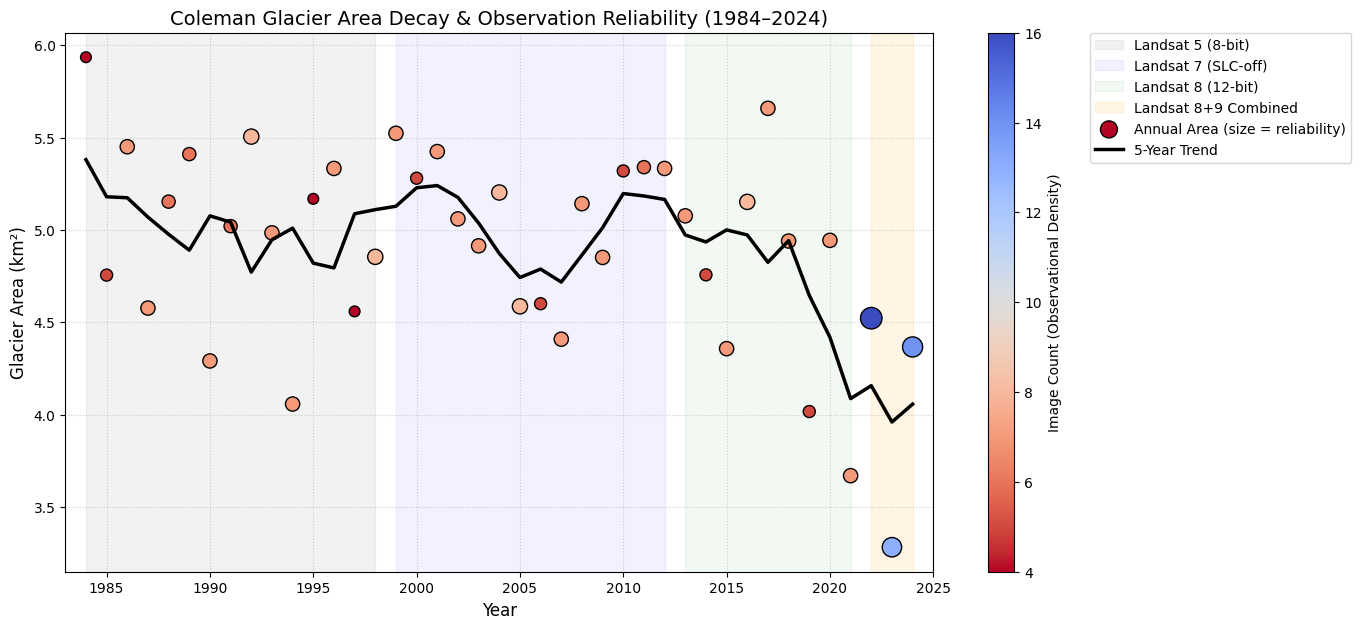

,Avg Images/Year,Min Images/Year,Max Images/Year,Total Years,Avg Area (km²)
sensor,,,,,
L5,6.20,4,8,15,5.00
L7,6.64,5,8,14,5.07
L8,6.67,5,8,9,4.73
L8+L9,14.33,13,16,3,4.06


In [29]:
plt.figure(figsize=(14, 7))

# 1. Update Shading for Sensor Eras
plt.axvspan(1984, 1998, color='gray', alpha=0.1, label='Landsat 5 (8-bit)')
plt.axvspan(1999, 2012, color='blue', alpha=0.05, label='Landsat 7 (SLC-off)')
plt.axvspan(2013, 2021, color='green', alpha=0.05, label='Landsat 8 (12-bit)')
plt.axvspan(2022, 2024, color='orange', alpha=0.1, label='Landsat 8+9 Combined')

# 2. Update the Rolling Calculations (Standardized for the full range)
# We use min_periods=1 so that the very start and end of the dataset still have data
df_glacier_final['glacier_5_moving_avg'] = df_glacier_final['glacier_area_km2'].rolling(window=5, center=True, min_periods=1).mean()

# 3. Plot Annual Area
# Note: I've added a color scale based on image count to highlight reliability
scatter = plt.scatter(df_glacier_final['year'], df_glacier_final['glacier_area_km2'],
            s=df_glacier_final['image_count']*15, # Increased multiplier for visibility
            c=df_glacier_final['image_count'], cmap='coolwarm_r', # High counts = Blue, Low = Red
            edgecolor='black', zorder=3, label='Annual Area (size = reliability)')

# 4. Plot the Trendline
plt.plot(df_glacier_final['year'], df_glacier_final['glacier_5_moving_avg'], 
         color='black', linewidth=2.5, linestyle='-', label='5-Year Trend', zorder=4)

# 5. Labels and Titles
plt.title('Coleman Glacier Area Decay & Observation Reliability (1984–2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Glacier Area (km²)', fontsize=12)
plt.xlim(1983, 2025)

cbar = plt.colorbar(scatter)
cbar.set_label('Image Count (Observational Density)', fontsize=10)

plt.legend(bbox_to_anchor=(1.18, 1), loc='upper left', borderaxespad=0., frameon=True)

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# 6. Updated Sensor Summary
sensor_summary = df_glacier_final.groupby('sensor')['image_count'].agg(['mean', 'min', 'max', 'count']).rename(
    columns={'mean': 'Avg Images/Year', 'min': 'Min Images/Year', 'max': 'Max Images/Year', 'count': 'Total Years'}
)

# Add average area to the summary for context
sensor_summary['Avg Area (km²)'] = df_glacier_final.groupby('sensor')['glacier_area_km2'].mean()

display(sensor_summary.round(2))




## Export

In [30]:
# export final glacier dataset as CSV
df_glacier_final.to_csv("../data/glacier_area.csv", index=False)

## Key Findings

Coleman Glacier has experienced sustained retreat over the satellite observation period (1984–2024).
- **Total area loss:** −1.57 km² between 1984 and 2024 (~26% reduction from the 1984 extent)
- **Retreat rate:** Linear regression estimates an average loss of **0.0180 km² per year**
- **Statistical significance:** The long-term retreat trend is statistically significant (**p = 0.0108**)
- **Interannual variability:** The relatively low R² (0.155) indicates substantial year-to-year variability, likely driven by fluctuations in snowpack, seasonal climate variability, and satellite observation conditions.
- **Overall trend:** Despite short-term variability, the long-term trajectory clearly indicates sustained glacier retreat.

# Climate Data Processing 

## Climate Data Source and Study Period

- Dataset: PRISM ANd daily climate data (1981–2020)
- Variables: mean temperature (tmean), precipitation (ppt)
- Study Area: Coleman Glacier region, North Cascades
- Melt Season: August 1 – September 30
- Pixel Resolution: 2.5 arc-minutes (~4.6 km at 48.8°N)

[PRISIM ANd dataset](https://developers.google.com/earth-engine/datasets/catalog/OREGONSTATE_PRISM_ANd)

Documentation: [PRISM Group](https://climatedataguide.ucar.edu/climate-data/prism-high-resolution-spatial-climate-data-united-states-maxmin-temp-dewpoint) | [PRISM PDF](https://prism.oregonstate.edu/documents/PRISM_datasets.pdf)



## Climate Data Handling

### Load PRISM Daily Collections

In [31]:
# select the PRISM dataset
prism_daily = ee.ImageCollection("OREGONSTATE/PRISM/ANd") 


### Extract Daily Climate Data

In [32]:
# filter collection to August/September months for 1984-2020
melt_season_prism = prism_daily \
    .filter(ee.Filter.calendarRange(1984, 2024, 'year')) \
    .filter(ee.Filter.calendarRange(8, 9, 'month'))

# function to get stats for every image in that collection
def get_stats(img):
    date = img.date()
    stats = img.select(['tmean', 'ppt']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=glacier.geometry(),
        scale=4638
    )
    return ee.Feature(None, {
        'date': date.format('YYYY-MM-dd'),
        'year': date.get('year'),
        'tmean': stats.get('tmean'),
        'ppt': stats.get('ppt')
    })

daily_climate_fc = melt_season_prism.map(get_stats)

# convert to pandas
rows = [f['properties'] for f in daily_climate_fc.getInfo()['features']]
df_climate_daily = pd.DataFrame(rows)

### Data Cleaning and Preparation

In [33]:
# create copy
df_climate_final = df_climate_daily.copy()

# ensure datetime
df_climate_final['date'] = pd.to_datetime(df_climate_final['date'])

# create  date labels (Aug 01, Aug 02, etc) for plotting
df_climate_final['date_label'] = df_climate_final['date'].dt.strftime('%b %d')

# create a numeric 'plot_index' that follows the calendar to ensures Aug 1 is always the same "spot" on the X-axis for every year
df_climate_final['plot_index'] = df_climate_final['date'].dt.dayofyear

## Climate Data Summary

In [34]:
# display climate info
df_climate_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        2501 non-null   datetime64[ns]
 1   ppt         2501 non-null   float64       
 2   tmean       2501 non-null   float64       
 3   year        2501 non-null   int64         
 4   date_label  2501 non-null   object        
 5   plot_index  2501 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(1)
memory usage: 107.6+ KB


In [35]:
# statistical analysis
df_climate_final.describe().T

,count,mean,min,25%,50%,75%,max,std
date,2501,2004-08-30 15:13:10.243902592,1984-08-01 00:00:00,1994-08-16 00:00:00,2004-08-31 00:00:00,2014-09-15 00:00:00,2024-09-30 00:00:00,NaN
ppt,2501.0,5.427307,0.0,0.0,0.0,2.56005,213.2594,14.846056
tmean,2501.0,8.827267,-4.3543,5.027802,8.746554,12.63305,21.698943,4.960315
year,2501.0,2004.0,1984.0,1994.0,2004.0,2014.0,2024.0,11.834526
plot_index,2501.0,243.268293,213.0,228.0,243.0,259.0,274.0,17.615913


## Climate Forcing Visualizations

## Temperature vs Precipitation Scatter

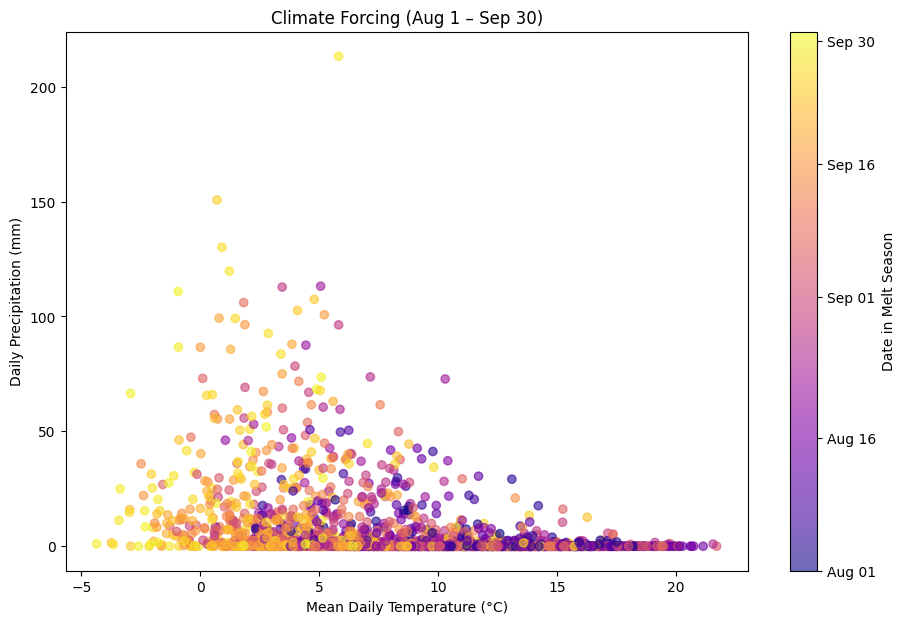

In [36]:
plt.figure(figsize=(11, 7))

# plot using the numeric 'plot_index' for color 'c'
scatter = plt.scatter(df_climate_final['tmean'], 
                      df_climate_final['ppt'], 
                      c=df_climate_final['plot_index'], 
                      cmap='plasma', 
                      alpha=0.6)

# create colorbar
cbar = plt.colorbar(scatter)

# set specific ticks for the start and middle of months
# (Aug 1 is ~213, Sept 1 is ~244)
tick_days = [213, 228, 244, 259, 273]
tick_labels = [pd.to_datetime(f"2023-{d}", format="%Y-%j").strftime('%b %d') for d in tick_days]

cbar.set_ticks(tick_days)
cbar.set_ticklabels(tick_labels)
cbar.set_label('Date in Melt Season')

plt.xlabel('Mean Daily Temperature (°C)')
plt.ylabel('Daily Precipitation (mm)')
plt.title('Climate Forcing (Aug 1 – Sep 30)')
plt.show()

### Average Melt Season Climate

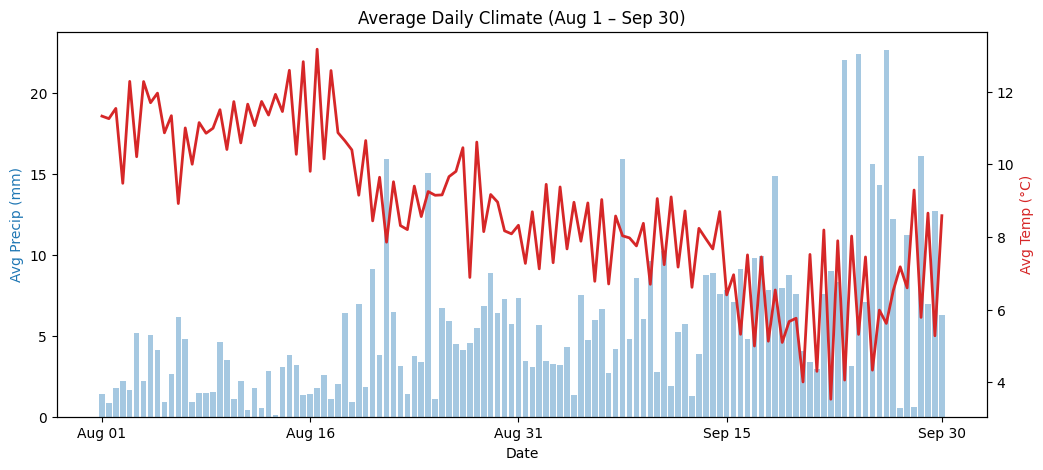

In [37]:
# group by numeric 'plot_index'
avg_climate = df_climate_final.groupby(['plot_index', 'date_label']).agg({
    'tmean': 'mean', 
    'ppt': 'mean' 
}).reset_index()

# plot mean temp and precipitation over time
fig, ax1 = plt.subplots(figsize=(12, 5))

x_numeric = range(len(avg_climate))

ax1.bar(x_numeric, avg_climate['ppt'], color='#1f77b4', alpha=0.4, label='Avg Precip')
ax2 = ax1.twinx()
ax2.plot(x_numeric, avg_climate['tmean'], color='#d62728', linewidth=2, label='Avg Temp')


# pick 5 even dates for x axis ticks
num_ticks = 5
indices = [int(i) for i in np.linspace(0, len(avg_climate) - 1, num_ticks)]
labels = [avg_climate['date_label'].iloc[i] for i in indices]

ax1.set_xticks(indices)
ax1.set_xticklabels(labels)

ax1.set_xlabel('Date')
ax1.set_ylabel('Avg Precip (mm)', color='#1f77b4')
ax2.set_ylabel('Avg Temp (°C)', color='#d62728')

plt.savefig('../figures/02_Avg_Daily_Climate.png', dpi=300, bbox_inches='tight')
plt.title('Average Daily Climate (Aug 1 – Sep 30)')
plt.show()

## Final Climate Dataset

In [38]:
# display first 5 rows and shape
display(df_climate_final.head())

print('\nShape:', df_climate_final.shape)

,date,ppt,tmean,year,date_label,plot_index
0,1984-08-01,0.597992,12.659654,1984,Aug 01,214
1,1984-08-02,1.349471,11.771050,1984,Aug 02,215
2,1984-08-03,8.847397,10.882959,1984,Aug 03,216
3,1984-08-04,3.162843,11.965207,1984,Aug 04,217
4,1984-08-05,1.870306,8.693347,1984,Aug 05,218



Shape: (2501, 6)


## Export


In [39]:
# export final climate dataset as CSV
df_climate_final.to_csv('../data/climate_variables.csv', index=False)


## Key Findings

- Melt season climate data were extracted for the Coleman Glacier region from 1984–2024 using the PRISM daily climate dataset, covering the late summer melt period (Aug 1 – Sep 30).
- The final dataset contains 2,501 daily observations spanning 41 melt seasons.
- **Mean daily temperature** during the melt season averaged **8.83 °C**, with values ranging from **−4.35 °C to 21.70 °C**, indicating substantial variability in late-summer thermal conditions.
- Typical melt-season temperatures fall between **~5.0 °C and 12.6 °C** (interquartile range), meaning most days occur well above freezing and are favorable for glacier melt.
- **Daily precipitation** averaged **5.43 mm**, but the distribution is highly skewed: over half of days recorded no precipitation, while extreme  events reached **213 mm**.
- The combination of frequent dry days and moderate temperatures suggests that glacier melt during this period is primarily influenced by temperature-driven energy balance rather than sustained precipitation events.
- These daily climate variables serve as meteorological forcing inputs for the subsequent analysis linking glacier area change and streamflow dynamics.